In [1]:



    #Objective: Reproduce AlN/W Dual Junction Performance JV curve, find the same global-maximum-efficiency point as Declan, and reproduce the MEP Map 


import numpy as np 
import matplotlib.pyplot as plt 
import scipy.integrate as integrate
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson 

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin
import sys 

import torch #pytorch 

    #This is all the relevant TMM Code written by Steven Byrnes 

EPSILON = sys.float_info.epsilon # typical floating-point calculation error

def make_2x2_array(a, b, c, d, dtype=float):
    """
    Makes a 2x2 numpy array of [[a,b],[c,d]]

    Same as "numpy.array([[a,b],[c,d]], dtype=float)", but ten times faster
    """
    my_array = np.empty((2,2), dtype=dtype)
    my_array[0,0] = a
    my_array[0,1] = b
    my_array[1,0] = c
    my_array[1,1] = d
    return my_array

def is_forward_angle(n, theta):
    """
    if a wave is traveling at angle theta from normal in a medium with index n,
    calculate whether or not this is the forward-traveling wave (i.e., the one
    going from front to back of the stack, like the incoming or outgoing waves,
    but unlike the reflected wave).
    
    For real n & theta, the criterion is simply
    -pi/2 < theta < pi/2, but for complex n & theta, it's more complicated.
    See https://arxiv.org/abs/1603.02720 appendix D.
    
    If theta is the forward angle, then (pi-theta) is the backward angle and vice-versa.
    """
    assert n.real * n.imag >= 0, ("For materials with gain, it's ambiguous which "
                                  "beam is incoming vs outgoing. See "
                                  "https://arxiv.org/abs/1603.02720 Appendix C.\n"
                                  "n: " + str(n) + "   angle: " + str(theta))
    ncostheta = n * cos(theta)
    if abs(ncostheta.imag) > 100 * EPSILON:
        # Either evanescent decay or lossy medium. Either way, the one that
        # decays is the forward-moving wave
        answer = (ncostheta.imag > 0)
    else:
        # Forward is the one with positive Poynting vector
        # Poynting vector is Re[n cos(theta)] for s-polarization or
        # Re[n cos(theta*)] for p-polarization, but it turns out they're consistent
        # so I'll just assume s then check both below
        answer = (ncostheta.real > 0)
    # convert from numpy boolean to the normal Python boolean
    answer = bool(answer)
    # double-check the answer ... can't be too careful!
    error_string = ("It's not clear which beam is incoming vs outgoing. Weird"
                    " index maybe?\n"
                    "n: " + str(n) + "   angle: " + str(theta))
    if answer is True:
        assert ncostheta.imag > -100 * EPSILON, error_string
        assert ncostheta.real > -100 * EPSILON, error_string
        assert (n * cos(theta.conjugate())).real > -100 * EPSILON, error_string
    else:
        assert ncostheta.imag < 100 * EPSILON, error_string
        assert ncostheta.real < 100 * EPSILON, error_string
        assert (n * cos(theta.conjugate())).real < 100 * EPSILON, error_string
    return answer

def snell(n_1, n_2, th_1):
    """
    return angle theta in layer 2 with refractive index n_2, assuming
    it has angle th_1 in layer with refractive index n_1. Use Snell's law. Note
    that "angles" may be complex!!
    """
    # Important that the arcsin here is numpy.lib.scimath.arcsin, not
    # numpy.arcsin! (They give different results e.g. for arcsin(2).)
    th_2_guess = arcsin(n_1*np.sin(th_1) / n_2)
    if is_forward_angle(n_2, th_2_guess):
        return th_2_guess
    else:
        return pi - th_2_guess #gives angle of reflected wave -- Bryant 

def list_snell(n_list, th_0):
    """
    return list of angle theta in each layer based on angle th_0 in layer 0,
    using Snell's law. n_list is index of refraction of each layer. Note that
    "angles" may be complex!!
    """
    # Important that the arcsin here is numpy.lib.scimath.arcsin, not
    # numpy.arcsin! (They give different results e.g. for arcsin(2).)
    angles = arcsin(n_list[0]*np.sin(th_0) / n_list)
    # The first and last entry need to be the forward angle (the intermediate
    # layers don't matter, see https://arxiv.org/abs/1603.02720 Section 5)
    if not is_forward_angle(n_list[0], angles[0]):
        angles[0] = pi - angles[0]
    if not is_forward_angle(n_list[-1], angles[-1]):
        angles[-1] = pi - angles[-1]
    return angles


def interface_r(polarization, n_i, n_f, th_i, th_f): #calculates the reflection coefficient at the interface between two layers
    """
    reflection amplitude (from Fresnel equations)

    polarization is either "s" or "p" for polarization

    n_i, n_f are (complex) refractive index for incident and final

    th_i, th_f are (complex) propegation angle for incident and final
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if polarization == 's':
        return ((n_i * cos(th_i) - n_f * cos(th_f)) /
                (n_i * cos(th_i) + n_f * cos(th_f)))
    elif polarization == 'p':
        return ((n_f * cos(th_i) - n_i * cos(th_f)) /
                (n_f * cos(th_i) + n_i * cos(th_f)))
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def interface_t(polarization, n_i, n_f, th_i, th_f): #calculates the transmission coefficient at the interface between two layers
    """
    transmission amplitude (frem Fresnel equations)

    polarization is either "s" or "p" for polarization

    n_i, n_f are (complex) refractive index for incident and final

    th_i, th_f are (complex) propegation angle for incident and final
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if polarization == 's':
        return 2 * n_i * cos(th_i) / (n_i * cos(th_i) + n_f * cos(th_f))
    elif polarization == 'p':
        return 2 * n_i * cos(th_i) / (n_f * cos(th_i) + n_i * cos(th_f))
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def R_from_r(r):
    """
    Calculate reflected power R, starting with reflection amplitude r.
    """
    return abs(r)**2

def T_from_t(pol, t, n_i, n_f, th_i, th_f):
    """
    Calculate transmitted power T, starting with transmission amplitude t.

    n_i,n_f are refractive indices of incident and final medium.

    th_i, th_f are (complex) propegation angles through incident & final medium
    (in radians, where 0=normal). "th" stands for "theta".

    In the case that n_i,n_f,th_i,th_f are real, formulas simplify to
    T=|t|^2 * (n_f cos(th_f)) / (n_i cos(th_i)).

    See https://arxiv.org/abs/1603.02720 for discussion of formulas
    """
    if pol == 's':
        return abs(t**2) * (((n_f*cos(th_f)).real) / (n_i*cos(th_i)).real)
    elif pol == 'p':
        return abs(t**2) * (((n_f*conj(cos(th_f))).real) /
                                (n_i*conj(cos(th_i))).real)
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def power_entering_from_r(pol, r, n_i, th_i):
    """
    Calculate the power entering the first interface of the stack, starting with
    reflection amplitude r. Normally this equals 1-R, but in the unusual case
    that n_i is not real, it can be a bit different than 1-R. See
    https://arxiv.org/abs/1603.02720

    n_i is refractive index of incident medium.

    th_i is (complex) propagation angle through incident medium
    (in radians, where 0=normal). "th" stands for "theta".
    """
    if pol == 's':
        return ((n_i*cos(th_i)*(1+conj(r))*(1-r)).real
                     / (n_i*cos(th_i)).real)
    elif pol == 'p':
        return ((n_i*conj(cos(th_i))*(1+r)*(1-conj(r))).real
                      / (n_i*conj(cos(th_i))).real)
    else:
        raise ValueError("Polarization must be 's' or 'p'")

def interface_R(polarization, n_i, n_f, th_i, th_f):
    """
    Fraction of light intensity reflected at an interface.
    """
    r = interface_r(polarization, n_i, n_f, th_i, th_f)
    return R_from_r(r)

def interface_T(polarization, n_i, n_f, th_i, th_f):
    """
    Fraction of light intensity transmitted at an interface.
    """
    t = interface_t(polarization, n_i, n_f, th_i, th_f)
    return T_from_t(polarization, t, n_i, n_f, th_i, th_f)

def coh_tmm(pol, n_list, d_list, th_0, lam_vac):
    """
    Main "coherent transfer matrix method" calc. Given parameters of a stack,
    calculates everything you could ever want to know about how light
    propagates in it. (If performance is an issue, you can delete some of the
    calculations without affecting the rest.)

    pol is light polarization, "s" or "p".

    n_list is the list of refractive indices, in the order that the light would
    pass through them. The 0'th element of the list should be the semi-infinite
    medium from which the light enters, the last element should be the semi-
    infinite medium to which the light exits (if any exits).

    th_0 is the angle of incidence: 0 for normal, pi/2 for glancing(grazing incidence).
    Remember, for a dissipative incoming medium (n_list[0] is not real), th_0
    should be complex so that n0 sin(th0) is real (intensity is constant as
    a function of lateral position).

    d_list is the list of layer thicknesses (front to back). Should correspond
    one-to-one with elements of n_list. First and last elements should be "inf".

    lam_vac is vacuum wavelength of the light.
    
    This function, like everything else in the package, implicitly requires you
    to pick a unit of length.You can use any unit, but keep it consistent.
    For example, if you input the wavelength in nanometers, then you must also
    input the layer thicknesses in nanometers. And then any angular wavenumber
    outputs will be in radians per nanometer, and any absorption outputs will
    be in (fraction of incoming light power per nanometer of depth), and so on.

    Then the function outputs the following as a dictionary (see
    https://arxiv.org/abs/1603.02720 for details)

    * r--reflection amplitude
    * t--transmission amplitude
    * R--reflected wave power (as fraction of incident)
    * T--transmitted wave power (as fraction of incident)
    * power_entering--Power entering the first layer, usually (but not always)
      equal to 1-R (see https://arxiv.org/abs/1603.02720 ).
    * vw_list-- n'th element is [v_n,w_n], the forward- and backward-traveling
      amplitudes, respectively, in the n'th medium just after interface with
      (n-1)st medium.
    * kz_list--normal component of complex angular wavenumber for
      forward-traveling wave in each layer.
    * th_list--(complex) propagation angle (in radians) in each layer
    * pol, n_list, d_list, th_0, lam_vac--same as input

    """
    # Convert lists to numpy arrays if they're not already.
    n_list = array(n_list)
    d_list = array(d_list, dtype=float)

    # Input tests
    if ((hasattr(lam_vac, 'size') and lam_vac.size > 1)
          or (hasattr(th_0, 'size') and th_0.size > 1)):
        raise ValueError('This function is not vectorized; you need to run one '
                         'calculation at a time (1 wavelength, 1 angle, etc.)')
    if (n_list.ndim != 1) or (d_list.ndim != 1) or (n_list.size != d_list.size):
        raise ValueError("Problem with n_list or d_list!")
    assert d_list[0] == d_list[-1] == inf, 'd_list must start and end with inf!'
    assert abs((n_list[0]*np.sin(th_0)).imag) < 100*EPSILON, 'Error in n0 or th0!'
    assert is_forward_angle(n_list[0], th_0), 'Error in n0 or th0!'
    num_layers = n_list.size

    # th_list is a list with, for each layer, the angle that the light travels
    # through the layer. Computed with Snell's law. Note that the "angles" may be
    # complex!
    th_list = list_snell(n_list, th_0)

    # kz is the z-component of (complex) angular wavevector for forward-moving (i.e. it's Beta) 
    # wave. Positive imaginary part means decaying.
    kz_list = 2 * np.pi * n_list * cos(th_list) / lam_vac

    # delta is the total phase accrued by traveling through a given layer.
    # Ignore warning about inf multiplication
    olderr = seterr(invalid='ignore')
    delta = kz_list * d_list
    seterr(**olderr)

    # For a very opaque layer, reset delta to avoid divide-by-0 and similar
    # errors. The criterion imag(delta) > 35 corresponds to single-pass
    # transmission < 1e-30 --- small enough that the exact value doesn't
    # matter.
    for i in range(1, num_layers-1):
        if delta[i].imag > 35:
            delta[i] = delta[i].real + 35j
            if 'opacity_warning' not in globals():
                global opacity_warning
                opacity_warning = True
                print("Warning: Layers that are almost perfectly opaque "
                      "are modified to be slightly transmissive, "
                      "allowing 1 photon in 10^30 to pass through. It's "
                      "for numerical stability. This warning will not "
                      "be shown again.")

    # t_list[i,j] and r_list[i,j] are transmission and reflection amplitudes,
    # respectively, coming from i, going to j. Only need to calculate this when
    # j=i+1. (2D array is overkill but helps avoid confusion.)
    t_list = zeros((num_layers, num_layers), dtype=complex)
    r_list = zeros((num_layers, num_layers), dtype=complex)
    for i in range(num_layers-1):
        t_list[i,i+1] = interface_t(pol, n_list[i], n_list[i+1],
                                    th_list[i], th_list[i+1])
        r_list[i,i+1] = interface_r(pol, n_list[i], n_list[i+1],
                                    th_list[i], th_list[i+1])
    # At the interface between the (n-1)st and nth material, let v_n be the
    # amplitude of the wave on the nth side heading forwards (away from the
    # boundary), and let w_n be the amplitude on the nth side heading backwards
    # (towards the boundary). Then (v_n,w_n) = M_n (v_{n+1},w_{n+1}). M_n is
    # M_list[n]. M_0 and M_{num_layers-1} are not defined.
    # My M is a bit different than Sernelius's, but Mtilde is the same.
    M_list = zeros((num_layers, 2, 2), dtype=complex)
    for i in range(1, num_layers-1):
        M_list[i] = (1/t_list[i,i+1]) * np.dot(
            make_2x2_array(exp(-1j*delta[i]), 0, 0, exp(1j*delta[i]),
                           dtype=complex),
            make_2x2_array(1, r_list[i,i+1], r_list[i,i+1], 1, dtype=complex))
    Mtilde = make_2x2_array(1, 0, 0, 1, dtype=complex)
    for i in range(1, num_layers-1):
        Mtilde = np.dot(Mtilde, M_list[i])
    Mtilde = np.dot(make_2x2_array(1, r_list[0,1], r_list[0,1], 1,
                                   dtype=complex)/t_list[0,1], Mtilde)

    # Net complex transmission and reflection amplitudes
    r = Mtilde[1,0]/Mtilde[0,0]
    t = 1/Mtilde[0,0]

    # vw_list[n] = [v_n, w_n]. v_0 and w_0 are undefined because the 0th medium
    # has no left interface.
    vw_list = zeros((num_layers, 2), dtype=complex)
    vw = array([[t],[0]])
    vw_list[-1,:] = np.transpose(vw)
    for i in range(num_layers-2, 0, -1):
        vw = np.dot(M_list[i], vw)
        vw_list[i,:] = np.transpose(vw)

    # Net transmitted and reflected power, as a proportion of the incoming light
    # power.
    R = R_from_r(r)
    T = T_from_t(pol, t, n_list[0], n_list[-1], th_0, th_list[-1])
    power_entering = power_entering_from_r(pol, r, n_list[0], th_0)

    return {'r': r, 't': t, 'R': R, 'T': T, 'power_entering': power_entering,
            'vw_list': vw_list, 'kz_list': kz_list, 'th_list': th_list,
            'pol': pol, 'n_list': n_list, 'd_list': d_list, 'th_0': th_0,
            'lam_vac':lam_vac}

def unpolarized_RT(n_list, d_list, th_0, lam_vac): #input your n_list, thickness list, th_0 is just one value,a nd then loop over the wavelengths
    """
    Calculates reflected and transmitted power for unpolarized light.
    """

    s_data = coh_tmm('s', n_list, d_list, th_0, lam_vac)
    p_data = coh_tmm('p', n_list, d_list, th_0, lam_vac)
    R = (s_data['R'] + p_data['R']) / 2.
    T = (s_data['T'] + p_data['T']) / 2.
    return R, T #reflected power and transmitted power 

    """
    pol is light polarization, "s" or "p".

n_list is the list of refractive indices, in the order that the light would
    pass through them. The 0'th element of the list should be the semi-infinite
    medium from which the light enters, the last element should be the semi-
    infinite medium to which the light exits (if any exits).

th_0 is the angle of incidence: 0 for normal, pi/2 for glancing(grazing incidence).
    Remember, for a dissipative incoming medium (n_list[0] is not real), th_0
    should be complex so that n0 sin(th0) is real (intensity is constant as
    a function of lateral position).

d_list is the list of layer thicknesses (front to back). Should correspond
    one-to-one with elements of n_list. First and last elements should be "inf".

    This function, like everything else in the package, implicitly requires you
    to pick a unit of length.You can use any unit, but keep it consistent.
    For example, if you input the wavelength in nanometers, then you must also
    input the layer thicknesses in nanometers. And then any angular wavenumber
    outputs will be in radians per nanometer, and any absorption outputs will
    be in (fraction of incoming light power per nanometer of depth), and so on.
    """


#Section #1 
wl_array = []
n_W = []
k_W = []
n_AlN = []
k_AlN = []


nk_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\W_AlN_Repro.txt"

with open(nk_data, "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline() # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f:
        if not line.strip():
            continue # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined

        wl, W_n, AlN_n, W_k, AlN_k = line.split() #splits up the columns in the spreadsheet and assigns them to each respective variable, does it row by row or 'line by line'

        wl_array.append(float(wl)) #storing the wavelengths,
        n_W.append(float(W_n)) #storing n-data for W
        k_W.append(float(W_k)) #storing the k-data for W
        n_AlN.append(float(AlN_n)) #storing the n-data for AlN 
        k_AlN.append(float(AlN_k))

wl_array = np.array(wl_array)   #in units of nm 
n_W = np.array(n_W)
k_W = np.array(k_W)
n_AlN = np.array(n_AlN)
k_AlN = np.array(k_AlN)

mask = wl_array <= 3000         #Keeping only the values that are less than or equal to 3000 nm; but I might change this upper limit (07-28-26) 

wl_array = wl_array[mask]       #[nm] --> I typically have quantities in SI units so if I ever need to troublehshoot it's always worth checking the units here. 
n_W = n_W[mask]
k_W = k_W[mask]
n_AlN = n_AlN[mask]
k_AlN = k_AlN[mask]

n_complex_W = n_W + 1j * k_W        #Fully consructed complex refrative indices of thin film structure
n_complex_AlN = n_AlN + 1j * k_AlN

#physical constants 
h_J = 6.626 * 1E-34              #planck's constant in Joule-seconds
h_eV = 4.136 * 1E-15             #planck's constant in eV-seconds 
c = 3*1E8                        #speed of light in m/s 
kb_J = 1.3806 * 1E-23            #boltzmann constant in  Joule/Kelvin 
kb_eV = 8.6173 * 1E-5            #boltzmann constant in eV/Kelvin 
q = 1.602 * 1E-19                #charge of an electron in Coulombs 

In [2]:
#Section #2: Beginning the TMM Calculations to determine Emissivity of the AlN/W bilayer --> using TMM_fast package

"""
To calculate the emissivity you need to follow these steps:

1) Create your refractive index array/tensor. The dimensions of this tensor, N, are (S x L x W) where S = num_stacks, L = num_layers, and W = the wavelength array you want to calculate R, T, and A over 

2) Create your thickness array. This has dimensions of (S x L) and is independent of wavelength. One caveat that I've noticed so far is that you can't do incoherent calculations. 

3) Check that all inputs are np.arrays or pytorch tensors 

4) Compute over s and p polarizations to simulate unpolarized light. 

"""

from tmm_fast import coh_tmm as tmm

wl = wl_array             #Not a necessary step, just did this to follow what was in the example on the tmm_fast page 

wl = torch.from_numpy(wl) #converting it from a numpy array --> pytorch tensor. the coh_tmm function requires that every parameter be the same format (i.e. all arrays or all tensors) 

theta = torch.zeros(1)    #Only calculating for normal incidence at the moment. If I wanted multiple angles then I'd use np.linspace or the pytorch equivalent. 
num_layers = 3            #I have three layers, Air/AlN/W where Air is semi-infinite, and W is usually semi-infinite. AlN ranges from 1 nm --> 1000nm 
num_stacks = 1000         #When I vary the thickness, each bilayer is its own unique stack. Thus, the number of layer thicknesses = number of stacks that I have. (stack == multilayer thin film) 

#create N (refractive index array/tensor) 
N = np.ones((num_stacks, num_layers, wl.shape[0]), dtype = 'complex')

"""
.shape[0] --> # of rows, .shape[1] --# of columns, and slicing at an index > 1 is accessing 3D or higher-dimensional parameters of the array. 

N = 3D array/tensor, where there are (wl.shape[0]) number of (num_stacks, num_layers) sized arrays

Since it's full of ones, if you have air as your first layer, the first column doesn't have to be modified. 
Everything else has to be modified to match your desired multilayer thin film(s) 
"""

for i in range(0, wl.shape[0]):           #start the range at 0 to include the 0th layer (air), and go up to wl.shape[0] --> index of substrate layer
    N[:, 1, i] = n_complex_AlN[i]         #fills in the second layer with wavelength dependent refractive indices of AlN                                   
    N[:, -1, i] = n_complex_W[i]          #fills in the last layer w/ wavelength dependent refractive indices of W                                       

   
N = torch.from_numpy(N)                   #converting this to a Torch Tensor



"""
def optical_thickness(lam, k):               #unitless quantity; This ends up not being used in this version of the code (08/04/26) 
    return (4 * np.pi * d_sub) * k / lam     #where k and lam are the imaginary part of the refractive index and the wavelength, respectively 

#for i in range(0, len(d_coating)): #inherently, this loop is kind of unnecessary because the whole package assumes that we're doing coherent calculations. If it was incoherent I'd have to use a different logic 
#for j, k in enumerate(k_W):    #because this loop basically says, "if it's transparent at ANY wavelength, then set the thickness for all wavelengths to be d_sub.          
    #if optical_thickness(wl_array[j], k) > 12:
        #T[i,2] = np.inf 
    #else:
        #T[i,2] = d_sub
"""

#Create thickness array

d_coating = np.arange(1,1001, 1)            #np.arange(a, b, step size) creates an array beginning at a --> up to b, but not including b. Indexing starts at 0
d_sub = 1E5                                 #if the optical thickness is NOT opaque then the substrate thickness is 10,000 nm (i.e. 0.1 mm) 
T = np.ones((num_stacks, num_layers))       #initializing the array, can use np.zeros, ones, etc. 

T[:,0] = np.inf                             #assigning the very first layer thickness to be infinite; because air is always going to be a semi-infinite layer if it's the very first layer. 

for i in range(0, len(d_coating)):
    T[i,1] = d_coating[i]

T[:,-1] = np.inf

T = torch.from_numpy(T)


#Calculating reflectivity. If it was transparent you'd have to set E = A = 1 - R - T. Otherwise, just set E = A = 1 - R 

tmm_s_results = tmm('s', N, T, theta, wl, device = 'cpu') #the outputs of this function are dictionaries. 
tmm_p_results = tmm('p', N, T, theta, wl, device = 'cpu') #The keys are 'r', 't', 'R', and 'T' with each having shape (num_stacks, theta.shape[0], and wl.shape[0])

R_avg = (tmm_s_results['R'] + tmm_p_results['R']) * 0.5   #average Reflectance over both polarizations 

emissivity = 1 - R_avg 

emissivity_ALL = emissivity.numpy()                           #converting it back to a numpy array so that it can be plotted easily with matplotlib 

C:\Users\bryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tmm_fast\vectorized_tmm_dispersive_multistack.py:152: UserWarning: Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.
You might encounter problems with gradient computation...
  warn('Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.\n'+


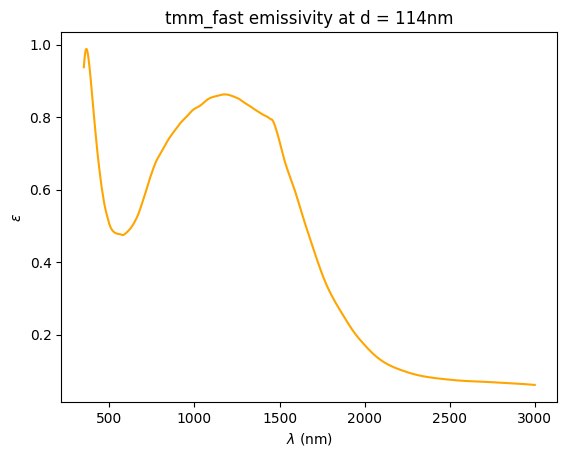

In [3]:

#Checking to see if the emissivity is actually correct 
"""
emissivity[row_index(multilayer-emitter with specific thickness), column_index(Angle), wavelength_index] --> I only have 1 angle, so to flatten the array into 1D I can just use 0 for the column index.

If I had multiple angles, I'd have to essentially create a heat map where the y-axis is angles, x-axis is wavelength, each point on the 2D plot is an emissivity, refletivity, absorptivity, etc. 

emissivity_ALL[:,0,:] --> this is a 2D array. Each row corresponds to the emissivity over all wavelengths of a specific AlN thickness. 
emissivity_ALL[:,0,:].shape will verify this 

"""
plt.plot(wl.numpy(), emissivity_ALL[113, 0, :], color = 'orange')
plt.xlabel(r'$\lambda$ (nm)') 
plt.ylabel(r'$\epsilon$') 
plt.title(r'tmm_fast emissivity at d = 114nm')
plt.show()

In [10]:
#Section 3: Performance Metric Curve Calculations for the idealized Dual-Junction Cell with AlN/W emitter --> FulL Reproduction 

"""
T_emitter --> Emitter temperature in Kelvin (converted from Celsius, typically) 
T_c --> Cell Temperature (Kelvin)
P_deriv_target = 0.00 --> To find the maximum cell power, the derivative of P(V) must be set to 0, which is what this is for. 
Eg_Array --> Bandgaps that I want to test/try out 
"""

T_emitter = (1800 + 273.15)           #converting from 1800 C to Kelvin 
T_c = 300                             #Taking 300K to be the temperature of both cells because it's not specified 
P_deriv_target = 0.00                 #use this to find the voltage that leads to maximum power for a single cell 

Eg_Array = np.arange(0.5, 1.15, 0.05) #Array of bandgap values in [eV], ranging from 0.50eV to 1.10 eV
                                      #one thing to keep in mind is that for tandem-cells, the top cell must have the higher bandgap. This also means that 
                                      #When you're looping, you need to have pairs of values where one is greater than or equal to the other. 
                                      #in the case where the top and bottom cells have the same bandgap, this is equivalent to a single junction cell 
  

def lam_Bandgap(EG_eV):       #Returns Band gap wavelength in units of [m] 
    return h_eV * c / EG_eV   #Input MUST be in units of [eV]
    
def lam_BB_peak(Temperature): #From Wien's Displacement Law; this returns peak wavelength of the BB spectrum 
    return (b) / Temperature  #in units of [m] 


def EQE(lam, lam_Eg):                   #External Quantum Efficiency (Idealized) --> Step function assumes that lam is in nanometers 
    return np.where(lam < lam_Eg, 1, 0) #Output is Unitless, inputs must be in units of [nm] 


def BB_spectrum(lam, T):                #Blackbody Spectrum/Spectral Radiance: has units of W/m^3 if you input lam in [m] and T in [K] 
    numerator = (2 * h_J * c**2 )
    denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
    return numerator/denominator   

def n_B(lam, T):                        #Blackbody Photon Spectral Radiance: has units of [s^-1 * m^3] if you input lam in [m] and T in [K] 
    numerator = (2 * c)                                                     #numerator is in [m/s]
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #denominator in [m^4]
    return numerator/denominator   

def P_derivative(J_L, J_0, V):          #Needed to calculate the maximum power point for a single cell 
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def J(J_L, J_0, V):                     #Current-Density in units of [A/m^2] of the Tandem Cell 
    return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c)) - 1)
    #return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c))) #Declan uses this approximation in 02-20-25 Slides. 

def J_sc_approx(J_L, J_0):
    #return J_L - J_0 #approximate value, doesn't make a huge difference if you use this or the other return 
    return J_L
def P_derivative(J_L, J_0, V):
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def P_cell_SJ_WCM2(wl_array, lam_Eg, emissivity, T_emitter, T_c): #Function for calculating cell power in [W/cm^2] for a single cell 

    n_B_array_LIGHT = n_B(wl_array, T_emitter)                   #the WL array in the argument must be in units of meters 
    n_B_array_DARK = n_B(wl_array, T_c)                          

    #Constructing the Ideal External Quantum Efficiency Function
    EQE_SF = EQE(wl_array * 1E9, lam_Eg * 1E9)                       #both things in the argument must be in units of nm; hence multiplication by 1E9 

    #Building the integrands 
    integrand_JL = q * np.pi * emissivity * n_B_array_LIGHT * EQE_SF #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                     #integrating it will give A/m^2 which is appropriate for current density. 
                                                                     #emissivity_TOP, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions. 
                                                                     #since it's the top cell, the integration limits are from (lambda_min --> lambda_max) 
                                                                                    
    integrand_J0 = q * np.pi * n_B_array_DARK * EQE_SF               #integrand of the dark-current, [A/m^2] 

    #Performing the Integration to obtain J_L and J_0 
    J_L = simpson(integrand_JL, x=wl_array)                          #light-induced current density given in [A/m^2]

    J_0 = simpson(integrand_J0, x=wl_array)                           #dark-current density given in [A/m^2]
    
    #Creating J-V Curve and Grabbing P_max 
    V_oc = (np.log((J_L / J_0) + 1)) * kb_eV * T_c  #in units of Volts, the open circuit voltage (I = 0)

    V_vals = np.linspace(0, V_oc, 200)              #creates the array of possible voltage values for IV curve

    P_derivs = P_derivative(J_L, J_0, V_vals)       #calculates the derivatives of Power wrt Voltage 
    
    differences = np.abs(P_derivs - P_deriv_target) #apart of finding where the voltage that produces P_max is  
    
    idx = np.argmin(differences) 
    
    V_pmax = V_vals[idx]         #voltage that produes P_max 
    
    J_pmax = J(J_L, J_0, V_pmax) # Current-density in A/m^2 that produces P_max 
    
    P_max = J_pmax * V_pmax      # Maximum Cell Power in units of W/m^2 

    P_cell = P_max * 1E-4        # Maximum cell power in units of W/cm^2 

    return P_cell 
    

def P_cell_DJ_WCM2(wl_array_TOP, wl_array_BOT, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP, emissivity_BOT, T_emitter, T_c):
                                                                         #Function for finding P_Cell in [W/cm^2] of a Dual-Junction Setup 
                                                                         #n_B spectra for light(T_e) and dark(T_c), wavelengths of emitter spetrum
                                                                         #emissivity --> scalar value or Array(must be same dimensions) 
                                                                         #wl_array_BOT will be another array that gets initialized, from [lambda_Eg_Top, --> end of spectrum]) 
                                                                         #***** ALL WAVELENGTHS MUST BE INPUT IN [m] *****

    #Constructing the Blackbody Spectral Photon Radiance Arrays for light & dark (for Top and Bottom)
    n_B_array_LIGHT_TOP = n_B(wl_array_TOP, T_emitter)                   #the WL array in the argument must be in units of meters 
    n_B_array_DARK_TOP = n_B(wl_array_TOP, T_c)                            
    n_B_array_LIGHT_BOT = n_B(wl_array_BOT, T_emitter)
    n_B_array_DARK_BOT = n_B(wl_array_BOT, T_c) 

    #Constructing the Ideal External Quantum Efficiency Functions for Top and Bottom Cells
    EQE_SF_TOP = EQE(wl_array_TOP * 1E9, lam_Eg_TOP * 1E9)                           #both things in the argument must be in units of nm; 
    EQE_SF_BOT = EQE(wl_array_BOT * 1E9, lam_Eg_BOT * 1E9)                           #related to the n_B_arrays, maybe the EQE is doing something weird as well. 
                                                                                     #similar thing here, using wl_array_TOP vs. wl_array_BOT in either of them doesn't change anything? 
    
    
    #These two integrands will be for the top-cell (higher bandgap material, always)
    
    integrand_JL_TOP = q * np.pi * emissivity_TOP * n_B_array_LIGHT_TOP * EQE_SF_TOP #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                     #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                     #emissivity_TOP, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions. 
                                                                                     #since it's the top cell, the integration limits are from (lambda_min --> lambda_max) 
                                                                                    
    integrand_J0_TOP = q * np.pi * n_B_array_DARK_TOP * EQE_SF_TOP                   #integrand of the dark-current, [A/m^2] 
    

    #These two integrands will be for the bottom cell (lower bandgap material, always) 
    
    integrand_JL_BOT = q * np.pi * emissivity_BOT * n_B_array_LIGHT_BOT * EQE_SF_BOT  #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                      #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                      #emissivity_, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions.
                                                                                      #bottom cell only has integration limits of (lambda_min --> lam_Eg_top_

    integrand_J0_BOT = q * np.pi * n_B_array_DARK_BOT * EQE_SF_BOT

    #Performing the Integration to obtain J_L and J_0 
    J_L_TOP = simpson(integrand_JL_TOP, x=wl_array_TOP)                               #light-induced current density given in [A/m^2]; (TOP) --> integrated over entire wavelength array [m] 

    J_0_TOP = simpson(integrand_J0_TOP, x=wl_array_TOP)                               #dark-current density given in [A/m^2] (TOP), 

    J_L_BOT = simpson(integrand_JL_BOT, x=wl_array_BOT)                               #light-induced current density given in [A/m^2] (BOTTOM) --> Integrated only over the filtered wl array [m] 

    J_0_BOT = simpson(integrand_J0_BOT, x=wl_array_BOT)                               #Dark-current density given in [A/m^2] (BOTTOM) 

    #Calculating J_sc and seeing which one is limiting 

    J_sc_TOP = J_sc_approx(J_L_TOP, J_0_TOP)                                          #[A/m^2]

    J_sc_BOT = J_sc_approx(J_L_BOT, J_0_BOT)                                          #[A/m^2] 

    J_sc_DJ = np.min(np.array([J_sc_TOP, J_sc_BOT])) 
    
    #Constructing J-V Curve and Calculating Power 

    J_vals = np.linspace(0, J_sc_DJ, 200) 
    
    V_DJ = (np.log((J_L_TOP - J_vals) / J_0_TOP + 1) + np.log( (J_L_BOT - J_vals) / J_0_BOT + 1)) * kb_eV * T_c    
                                                                                      #Voltage in DJ Cell; in units of [V]

    Power = J_vals * V_DJ                                                             #Power[W/m^2]; element-wise multiplication of J_vals and V to obtain Power at each point on JV curve 

    P_max = np.max(Power)                                                         

    P_cell_DJ = P_max * 1E-4                                                          #Maximum cell power in units of W/cm^2 

        #These are for verification during initial code-write up; all in [V] 
    V_oc_TOP = kb_eV * T_c * np.log((J_L_TOP / J_0_TOP))
    V_oc_BOT = kb_eV * T_c * np.log((J_L_BOT / J_0_BOT))
    V_oc_DJ = V_oc_TOP + V_oc_BOT 

    V_vals_TOP = np.linspace(0, V_oc_TOP, 200) 
    V_vals_BOT = np.linspace(0, V_oc_BOT, 200) 

    JV_TOP = J(J_L_TOP, J_0_TOP, V_vals_TOP)                                          #[A/m^2]
    JV_BOT = J(J_L_BOT, J_0_BOT, V_vals_BOT)                                          #[A/m^2] 

    return P_cell_DJ, JV_TOP, JV_BOT, V_vals_TOP, V_vals_BOT, J_vals, V_DJ      
                                                                                      #If looping, need to create an array to contain all the P_cells 



# Beginning of the Calculations 

n = len(Eg_Array)                   # Creating an (n x n) array ensures that all (Eg_top, Eg_bot) pairs are accounted for, but for Eg_bot > Eg_top, that value will be 0(i.e. skipped over) 
P_cell_grid = np.zeros((n, n))      # P_cell grid (Maximum Power Point) of tandem cell [W/cm^2] 
efficiency_grid = np.zeros((n, n))  # Efficiency grid (Maximum Efficiency Point) of tandem cell [W/cm^2] 
coating_grid = np.zeros((n, n))     # Coating grid for each tandem cell [W/cm^2] 

#Quantities that are loop independent 

lower_int_lim = wl_array.min() #350 nm 
upper_int_lim = wl_array.max() #3000 nm 

lam_fine_TOP = np.linspace(lower_int_lim, upper_int_lim, 7500)    #creating an array of wavelength values with finely spaced points [nm] 
lam_fine_TOP_meters = lam_fine_TOP * 1E-9                          #converting that array to meters, so I can do the integration with the right units 

BB_radiance = BB_spectrum(lam_fine_TOP_meters, T_emitter)          #[W/m^3] 


#Calculating all emitted powers and top-cell emissivities, one for each coating thickness 
P_emit_all = []
emissivity_TOP_fine_ALL = [] 

for E in emissivity_ALL[:,0,:]:                                       #with tmm_fast the only change that I needed to make was flattening the emissivity array (08/04/26) 
    PC_emissivity = PchipInterpolator(wl_array, E)
    emissivity_TOP_fine = PC_emissivity(lam_fine_TOP)
    emissivity_TOP_fine_ALL.append(emissivity_TOP_fine)
    integrand_fine_emit = np.pi * emissivity_TOP_fine * BB_radiance
    P_emit = simpson(integrand_fine_emit, x=lam_fine_TOP_meters) * 1E-4
    P_emit_all.append(P_emit)
    
P_emit_all = np.array(P_emit_all)                                      #[W/cm^2] 
emissivity_TOP_fine_ALL = np.array(emissivity_TOP_fine_ALL)            #Unitless emissivity 

for i, Eg_t in enumerate(Eg_Array):

    lam_Eg_TOP = lam_Bandgap(Eg_t)                                     #corresponding wavelengths in units of [m] 
    idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))            #determines the index of (lam_Eg_TOP) in the wl_array
    
    lam_fine_BOT = np.linspace(wl_array[idx_Eg], upper_int_lim, 7500) #The top cell absorbs light w/ wavelengths <= its bandgap wavelength, so the bottom cell receives everything that's longer than that 
    lam_fine_BOT_meters = lam_fine_BOT * 1E-9                          #[m]

    
    emissivity_BOT_fine_ALL = []                                       #all interpolated emissivities for the bottom cells
    for E in emissivity_ALL[:,0,:]:                                    #looping over the emissivity values to determine which coating thickness is the most optimal 

        PC_emissivity = PchipInterpolator(wl_array, E)
        
        emissivity_BOT_fine = PC_emissivity(lam_fine_BOT)              #interpolated emissivity (experienced by Bottom Cell) 

        emissivity_BOT_fine_ALL.append(emissivity_BOT_fine)
        
    emissivity_BOT_fine_ALL = np.array(emissivity_BOT_fine_ALL)

        #Calculating cell power @ each thickness
    for j, Eg_b in enumerate(Eg_Array[:i+1]):#[:i + 1] means that it will only slice the array up to and inclduing that i-th value; For Eg_Top = Eg_Bot that is essentially single junction 
                                             #Eg_Array is in increasing order [eV], so slicing up to the ith value means only creating pairs where Eg_bot < Eg_top
        lam_Eg_BOT = lam_Bandgap(Eg_b) 
    

        cell_powers = []               #P_cell in [W/cm^2] --> Storing the cell powers to calculate efficiency with


        for k in range(len(emissivity_ALL)):
            emissivity_TOP_fine = emissivity_TOP_fine_ALL[k]
            emissivity_BOT_fine = emissivity_BOT_fine_ALL[k]
    
            if i == j:
                P_cell = P_cell_SJ_WCM2(lam_fine_TOP_meters, lam_Eg_TOP, emissivity_TOP_fine, T_emitter, T_c)
            else:
                P_cell = P_cell_DJ_WCM2(lam_fine_TOP_meters, lam_fine_BOT_meters, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP_fine, emissivity_BOT_fine, T_emitter, T_c)[0]
        
            cell_powers.append(P_cell)

        #Converting to np.arrays because I'm scared of math not being done right 
        cell_powers = np.array(cell_powers) 
        efficiency = cell_powers / P_emit_all * 100

        #Identifying MEP, 
        max_eta = np.max(np.round(efficiency, 3))  #maximum efficiency point
        idx_MEP = np.argmax(efficiency)            #index of maximum efficency point 

        
        P_cell_grid[i, j] = np.max(cell_powers)   #maximum power point [W/cm^2] 
        efficiency_grid[i, j] = max_eta           #storing maximum efficiency point [%]
        coating_grid[i, j] = d_coating[idx_MEP]   #storing coating thickness for MEP [%] 
        
        
        


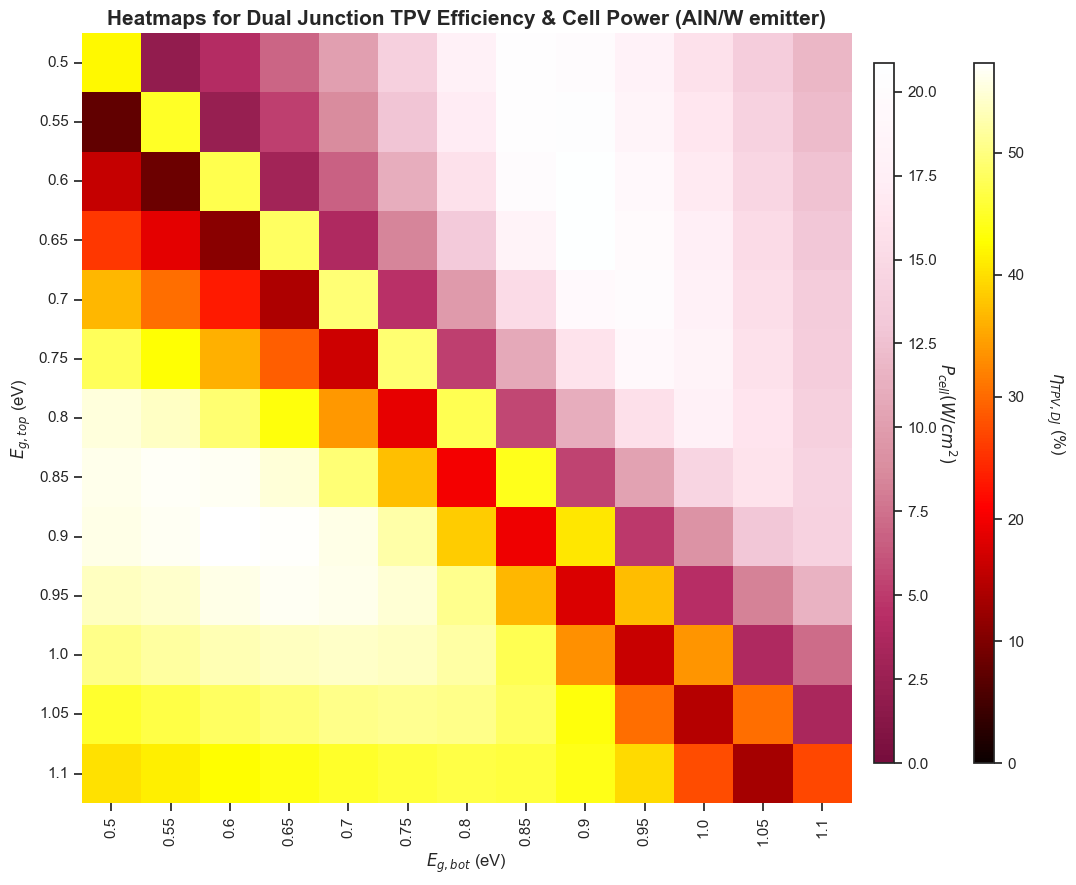

In [11]:
#Section 4: Creating the Heatmap 

"""
heat_map() is the function that creates the heatmaps. 
see more @ https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap



heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, 
        #square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)

"""

import seaborn as sns 
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap

newcolors = plt.get_cmap('PiYG', 256)(np.linspace(0, .48, 256))

for i in range(0,len(newcolors)):
    newcolors[i,0] = min(.027+newcolors[i,0]**1.4,1)
    newcolors[i,1] = min(.046+newcolors[i,1]**.9,1)
    newcolors[i,2] = min(.057+newcolors[i,2]**1.5,1)
    
newcmp = ListedColormap(newcolors) #updated colormap with 'newcolors' and this is a specific colormap, not a string defining the name of the cmap, so don't put quotes 



#actual plotting 


sns.set_theme(style = 'ticks')            #by default it has its own ticks unless you specify what kind of background you want 
fig, ax = plt.subplots(figsize = (10,10)) #I only need one ax because both heatmaps are going on the same ax



"""
To create this specific heatmap, I needed to do the following

1) Take the transpose of the P_cell_grid, so that way all of the values get repositioned to the upper right triangle/upper right corner

2) I needed to mask all the empty squares int he P_cell_grid transpose and the efficiency_grid. 

3) Plot both of them on the same ax(i.e. same plot) 

to better understand the mask, read it inside out

mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1)
    - np.ones_like(efficiency_grid, dtype = bool) --> creates an array of ones that has the same dimensions as efficiency grid, but the data-type of each entry is a boolean.
    - booleans are 1's and 0's.
    - 1's --> True, 0 --> false 
    - So np.ones_like(efficiency_grid, dtype = bool) ends up creating an array of 'True' values 
    np.triu(A , k = B) will zero out everything from the k = B row and onward of your A-array. So now the array is full of true-false values, and this mask gets fed to the function

mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0)

this all gets plotted onto ax, fig is the canvas 

"""

sns.heatmap(efficiency_grid, vmin = 0, vmax = np.max(efficiency_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = False, mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax, cbar = False, square = True)


sns.heatmap(P_cell_grid.T, vmin = 0, vmax = np.max(P_cell_grid.T), cmap = newcmp, xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = False, mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0) , fmt = '.2f', ax = ax, cbar = False, square = True)
                    #plots the heatmap on its own ticks


# Colorbar for P_cell
sm_pcell = ScalarMappable(cmap = newcmp, norm=Normalize(vmin=0, vmax=np.max(P_cell_grid.T))) #basically defines the input of the colorbar. 
cbar_ax1 = fig.add_axes([0.92, 0.15, 0.02, 0.7])                                             #position of the colorbar [left, bottom, width, height] in figure coords
P_cell_CBAR = fig.colorbar(sm_pcell, cax=cbar_ax1)                                           #plotting the colorbar onto the figure using the input, sm_pcell, and the location, cbar_ax1 
P_cell_CBAR.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 15)               #labeling the color bar 

# Colorbar for efficiency
sm_eff = ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=np.max(efficiency_grid)))
cbar_ax2 = fig.add_axes([1.02, 0.15, 0.02, 0.7])  
eta_CBAR = fig.colorbar(sm_eff, cax=cbar_ax2)
eta_CBAR.set_label(r'$\eta_{TPV, DJ}$ (%)', rotation = 270, labelpad = 30) 


ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0)

ax.set_ylabel(r'$E_{g, top}$ (eV)') 
ax.set_xlabel(r'$E_{g, bot}$ (eV)') 


ax.set_title('Heatmaps for Dual Junction TPV Efficiency & Cell Power (AlN/W emitter)', fontsize = 15, fontweight = 'bold')



plt.show()



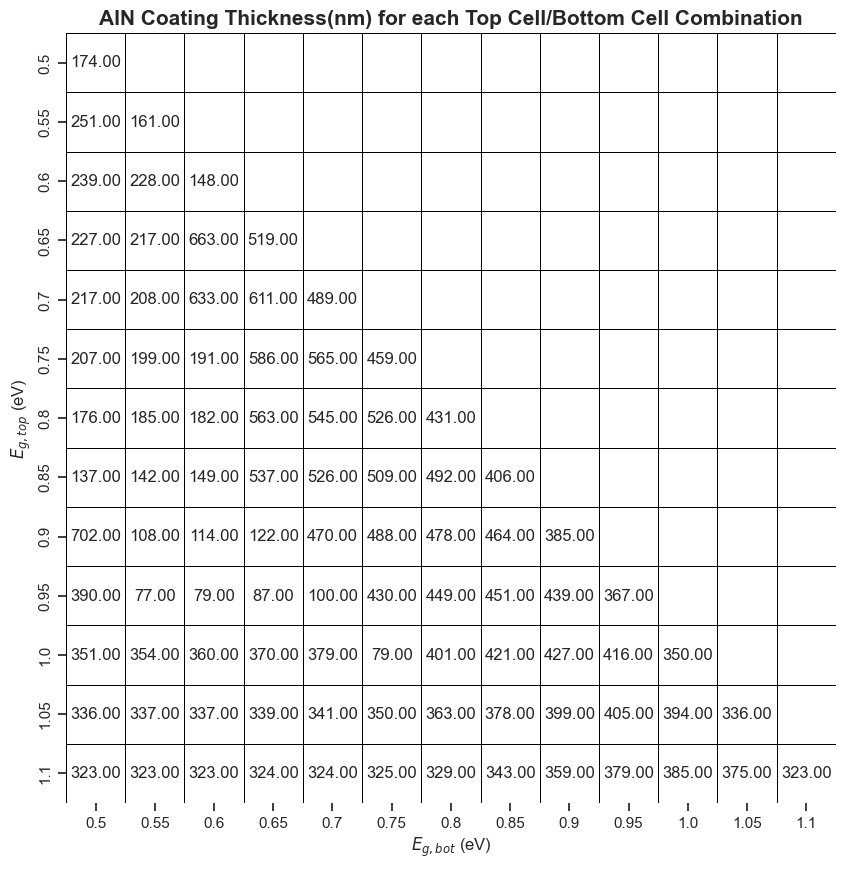

In [14]:
sns.set_theme(style = 'ticks') 
fig, ax2 = plt.subplots(figsize = (10,10))
sns.heatmap(coating_grid, vmin = 0, vmax = np.max(efficiency_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax2, cbar = False, square = True, linewidths = 0.5, linecolor = 'black')
ax2.set_ylabel(r'$E_{g, top}$ (eV)') 
ax2.set_xlabel(r'$E_{g, bot}$ (eV)')
ax2.set_title(r'AlN Coating Thickness(nm) for each Top Cell/Bottom Cell Combination', fontsize = 15, fontweight = 'bold')
plt.show()

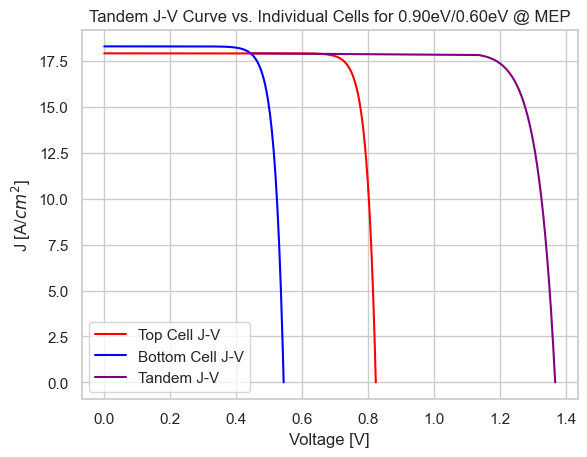

8 2
0.9000000000000004 0.6000000000000001
114.0


In [15]:

sns.set_theme(style = 'whitegrid')
i, j = np.unravel_index(np.argmax(efficiency_grid), efficiency_grid.shape)
d_coating_optimal = coating_grid[i, j]

lam_Eg_TOP = lam_Bandgap(Eg_Array[i])
lam_Eg_BOT = lam_Bandgap(Eg_Array[j])

idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))
idx_opt_coat = np.argmin(np.abs(d_coating - d_coating_optimal))

lam_fine_BOT_m = np.linspace(wl_array[idx_Eg], upper_int_lim, 10000) * 1E-9

E_optimal = emissivity_ALL[idx_opt_coat,0,:]
PC_emissivity_opt = PchipInterpolator(wl_array, E_optimal)
emissivity_TOP_at_MEP = PC_emissivity_opt(lam_fine_TOP)
emissivity_BOT_at_MEP = PC_emissivity_opt(lam_fine_BOT_m * 1e9)

P_cell_plot, JV_TOP, JV_BOT, V_vals_TOP, V_vals_BOT, J_vals, V_DJ = P_cell_DJ_WCM2(
    lam_fine_TOP_meters, lam_fine_BOT_m, lam_Eg_TOP, lam_Eg_BOT,
    emissivity_TOP_at_MEP, emissivity_BOT_at_MEP, T_emitter, T_c)

plt.plot(V_vals_TOP, JV_TOP * 1E-4, color='red', label='Top Cell J-V')
plt.plot(V_vals_BOT, JV_BOT * 1E-4, color='blue', label='Bottom Cell J-V')
plt.plot(V_DJ, J_vals * 1E-4, color='purple', label='Tandem J-V')
plt.xlabel('Voltage [V]')
plt.ylabel(r'J [A/$cm^{2}$]')
plt.title(rf'Tandem J-V Curve vs. Individual Cells for {Eg_Array[i]:.2f}eV/{Eg_Array[j]:.2f}eV @ MEP')
plt.legend()
plt.show()

print(i, j)
print(Eg_Array[i], Eg_Array[j])
print(d_coating_optimal)